In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from modules import SAB, ISAB, PMA
from models import DeepSet, SetTransformer, CondSM
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [48]:
num_epochs = 200
aggr_type = 'sum'
coord_model_type = 'ds'
coord_h_dim = 90
coord_out_dim = 10 
num_electrodes = 7
sm_in_dim = num_electrodes + coord_out_dim
sm_h_dim = 90
sm_layer_dims = [sm_in_dim, sm_h_dim, sm_h_dim, sm_h_dim, 1]
dp = 0.1
bn = True

if coord_model_type == 'ds':
    state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/models/{coord_model_type}_epochs={num_epochs}_aggr={aggr_type}_coord_h_dim={coord_h_dim}_coord_l_dim={coord_out_dim}.pth', weights_only=False, map_location='cpu')
    coord_model = DeepSet(in_dim=2, h_dim=coord_h_dim, num_outputs=1, out_dim=coord_out_dim, aggr_type=aggr_type)
    coord_model.load_state_dict(state_dict=state_dict['coord_model_state_dict'])

    cond_model = CondSM(layer_dims=sm_layer_dims, dropout_p=dp, batch_norm=bn)
    cond_model.load_state_dict(state_dict['cond_model_state_dict'])
    
    train_losses = state_dict['train_losses']
    val_losses = state_dict['val_losses']
    
elif coord_model_type == 'st':
    state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/models/{coord_model_type}_epochs={num_epochs}_aggr={aggr_type}_coord_h_dim={coord_h_dim}_coord_l_dim={coord_out_dim}.pth', weights_only=False, map_location='cpu')
    coord_model = SetTransformer(in_dim=2, num_outputs=1, out_dim=coord_out_dim)
    coord_model.load_state_dict(state_dict=state_dict['coord_model_state_dict'])

    cond_model = CondSM(layer_dims=sm_layer_dims, dropout_p=dp, batch_norm=bn)
    cond_model.load_state_dict(state_dict['cond_model_state_dict'])
    
    train_losses = state_dict['train_losses']
    val_losses = state_dict['val_losses']

In [30]:
from utils import create_dopant_configuration

radius = 150.0

for i in range(4):
    acc_angles, don_angles, r_acc, r_don = create_dopant_configuration(
        radius, 
        n_a=200, 
        n_d=3, 
        name_a=f'multi_cfg', 
        name_d='test_don_uni', 
        mode='uniform', 
        eps=None, 
        save_dir='/home/hd/hd_hd/hd_gy283/kmc_project/configs/'
    )
    
    acc = np.loadtxt(f'/home/hd/hd_hd/hd_gy283/kmc_project/configs/multi_cfg.txt')
    acc = acc / radius

#fig, ax = plt.subplots(figsize=(4,4))
#ax.scatter(*acc.T, s=12.5)

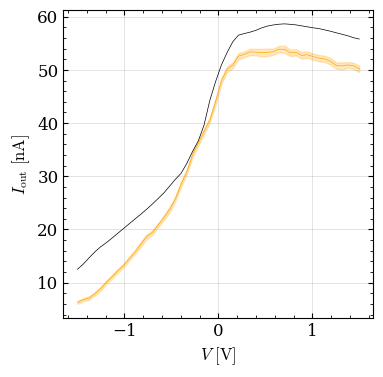

In [73]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

coord_model.eval()
cond_model.eval()

cfg_idx = 3
acc_cfg = np.loadtxt(f'/home/hd/hd_hd/hd_gy283/kmc_project/configs/multi_cfg_test_acceptors_{cfg_idx}.txt')
#acc_cfg = np.loadtxt(f'/home/hd/hd_hd/hd_gy283/kmc_project/configs/radial_distribution.txt')
acc = acc_cfg / radius

coord_model = coord_model.to(device)
cond_model = cond_model.to(device)

N = 50
c_list = [0.2, 1.1, -0.5, -1, 0.5, 0.7]
c_volts = torch.tensor(c_list, dtype=torch.float32).expand(N, -1)
volt_range = torch.linspace(-1.5, 1.5, N).unsqueeze(1)

input_tensor = torch.cat([volt_range, c_volts], dim=1)
geom_tensor = torch.from_numpy(acc).float().unsqueeze(0).expand(N, 200, 2)

input_tensor = input_tensor.to(device)
geom_tensor = geom_tensor.to(device)

with torch.no_grad():
    z = coord_model(geom_tensor).squeeze(dim=1)  
    sm_input = torch.cat([input_tensor, z], axis=1)
    y = cond_model(sm_input).detach().cpu().numpy()
test_simulation = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/multi_cfg_test_curves/multi_cfg_test_iv_{cfg_idx}.npz')
current = test_simulation['current']*1e21
sem = test_simulation['sem']*1e21*1.96
vs = np.linspace(-1.5, 1.5, N)

fig, ax = plt.subplots(figsize=(4,4))
ax.minorticks_on()
ax.tick_params(direction='in', which='both')
ax.tick_params(right=True, top=True, which='both')
ax.grid(lw=0.5, alpha=0.5)
ax.set_xlabel(r'$V \, \, [\mathrm{V}]$')
ax.set_ylabel(r'$I_{\mathrm{out}} \, \, [\mathrm{nA}]$')
ax.plot(vs, y, c='k', lw=0.5, alpha=1.0)
ax.fill_between(vs, current-sem, current+sem, alpha=0.25, color='orange')
ax.plot(vs, current, lw=0.5, alpha=1.0, color='orange')

plt.show()